
# ЛР №2

_**Гаврилин Олег Сергеевич**_

_**Зорин Георгий Юрьевич**_



### Подготовка данных

In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold, ShuffleSplit, LeaveOneOut, GroupKFold, RepeatedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.metrics import make_scorer, mean_squared_error

# === Загрузка и подготовка данных ===
data = pd.read_csv("Tech_Use_Stress_Wellness.csv")

# Исключаем строки без значения целевой переменной
data = data[data["stress_level"].notna()]

# Формирование матрицы признаков и целевой переменной
features = ["age", "gender", "sleep_quality", "daily_screen_time_hours"]
target = "stress_level"

X = pd.get_dummies(data[features], drop_first=True)
y = data[target]

# Группировка наблюдений по типу местности
groups = data["location_type"]


### Настройка модели и метрик

In [7]:
# Модель: Ridge с нормализацией признаков
ridge_pipeline = Pipeline(steps=[
    ("norm", StandardScaler()),
    ("ridge", Ridge(alpha=1.0))
])

# Метрика RMSE для оценки модели
rmse_scorer = make_scorer(
    lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred)),
    greater_is_better=False
)


### Настройка разных видов кросс-валидации

In [10]:
cv_strategies = {
    # Классическая 5-кратная валидация с перемешиванием данных
    "KF_5fold": KFold(n_splits=5, shuffle=True, random_state=7),

    # Случайное разбиение: 70% обучающей, 30% тестовой выборки, повтор 5 раз
    "Shuffle_70_30": ShuffleSplit(n_splits=5, test_size=0.3, random_state=7),

    # Экстремальный случай: тестируется по одному объекту
    "LOO_full": LeaveOneOut(),

    # Проверка модели по социальному фактору — тип местности
    "By_Location": GroupKFold(n_splits=3),

    # Усреднение по нескольким запускам KFold с разным делением
    "RepeatedKF": RepeatedKFold(n_splits=6, n_repeats=3, random_state=7)
}

fold_groups = df["location_type"]


### Прогон модели по всем видам кросс-валидации

In [12]:
import warnings
from sklearn.model_selection import cross_validate
from numpy import nanmean

# Игнорируем предупреждения, чтобы не засоряли вывод
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

# --- Список для итогов ---
cv_summary = []

# --- Перебираем все стратегии ---
for label, splitter in cv_strategies.items():
    try:
        # Для GroupKFold требуется передавать группы отдельно
        if "Location" in label:
            result = cross_validate(
                estimator=pipe,
                X=X,
                y=y,
                cv=splitter,
                groups=fold_groups,
                scoring={"RMSE": rmse_scorer, "R2": "r2"}
            )
        else:
            result = cross_validate(
                estimator=pipe,
                X=X,
                y=y,
                cv=splitter,
                scoring={"RMSE": rmse_scorer, "R2": "r2"}
            )

        # Средние значения метрик (игнорируем NaN)
        mean_rmse = -nanmean(result["test_RMSE"])   # rmse_scorer использует отрицательные значения
        mean_r2 = nanmean(result["test_R2"])

        cv_summary.append({
            "Тип проверки": label,
            "Средний RMSE": round(mean_rmse, 3),
            "Средний R²": round(mean_r2, 3)
        })

    except Exception as err:
        print(f"Метод {label} пропущен: {err}")

cv_results = pd.DataFrame(cv_summary)
print("Сводная таблица по методам кросс-валидации:\n")
print(cv_results)


Сводная таблица по методам кросс-валидации:

    Тип проверки  Средний RMSE  Средний R²
0       KF_5fold         2.021       0.518
1  Shuffle_70_30         2.019       0.520
2       LOO_full         1.656         NaN
3    By_Location         2.016       0.521
4     RepeatedKF         2.021       0.519


### Визуализация сравнения

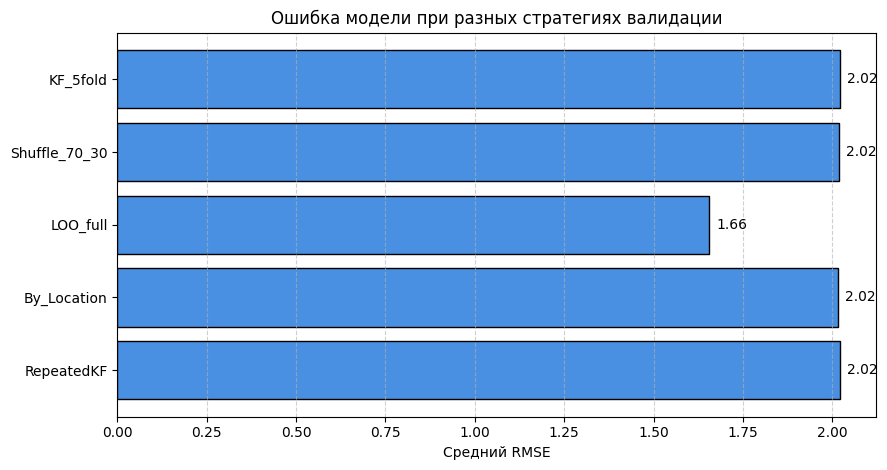

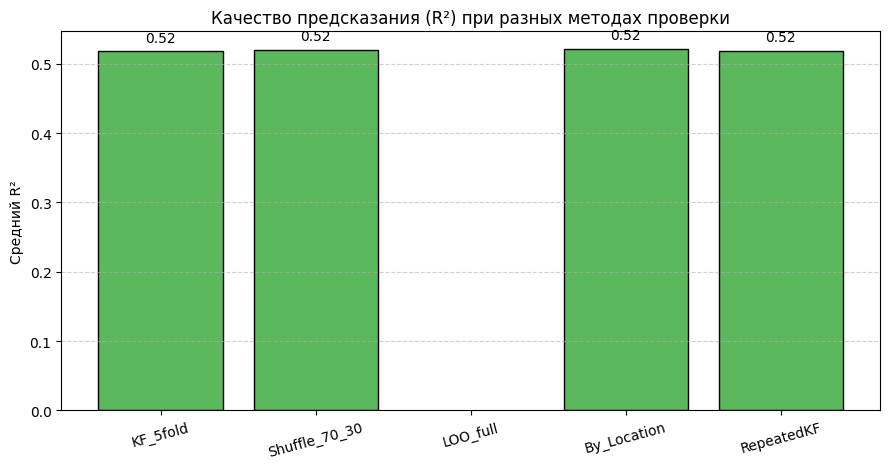

In [13]:
import matplotlib.pyplot as plt

# --- Визуализация результатов RMSE ---
plt.figure(figsize=(9, 4.8))
bars = plt.barh(
    cv_results["Тип проверки"],
    cv_results["Средний RMSE"],
    color="#4A90E2",
    edgecolor="black"
)
plt.xlabel("Средний RMSE")
plt.title("Ошибка модели при разных стратегиях валидации")
plt.grid(axis="x", linestyle="--", alpha=0.6)
plt.gca().invert_yaxis()  # чтобы лучший метод был сверху

# Добавим подписи к барам
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.02, bar.get_y() + bar.get_height()/2,
             f"{width:.2f}", va='center')

plt.tight_layout()
plt.show()

# --- Визуализация результатов R² ---
plt.figure(figsize=(9, 4.8))
bars2 = plt.bar(
    cv_results["Тип проверки"],
    cv_results["Средний R²"],
    color="#5CB85C",
    edgecolor="black"
)
plt.ylabel("Средний R²")
plt.title("Качество предсказания (R²) при разных методах проверки")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.xticks(rotation=15)

# Подписываем значения прямо на столбцах
for bar in bars2:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.01,
             f"{height:.2f}", ha='center', va='bottom')

plt.tight_layout()
plt.show()
